In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data1.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [4]:
# Переводим столбец "Дата" в формат datetime
df['Дата'] = pd.to_datetime(df['Дата'])

# Проверяем результат
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB
None
        Дата  Склад Контрагент Номенклатура  Количество
0 2018-01-04      1  address_0    product_0           4
1 2018-01-04      1  address_0    product_1           4
2 2018-01-04      1  address_0    product_2           5
3 2018-01-04      1  address_0    product_3          10
4 2018-01-04      1  address_0    product_4           2


Сгруппируйте данные по дате, посчитайте количество продаж

In [5]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

print(grouped_df)

          Дата  Количество
0   2018-01-04        3734
1   2018-01-05        3643
2   2018-01-06        3193
3   2018-01-07        3298
4   2018-01-09        4055
..         ...         ...
200 2018-08-26        5302
201 2018-08-28        5983
202 2018-08-29        4969
203 2018-08-30        4648
204 2018-08-31        4570

[205 rows x 2 columns]


Вывести несколько первых строк сгруппированных данных

In [6]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

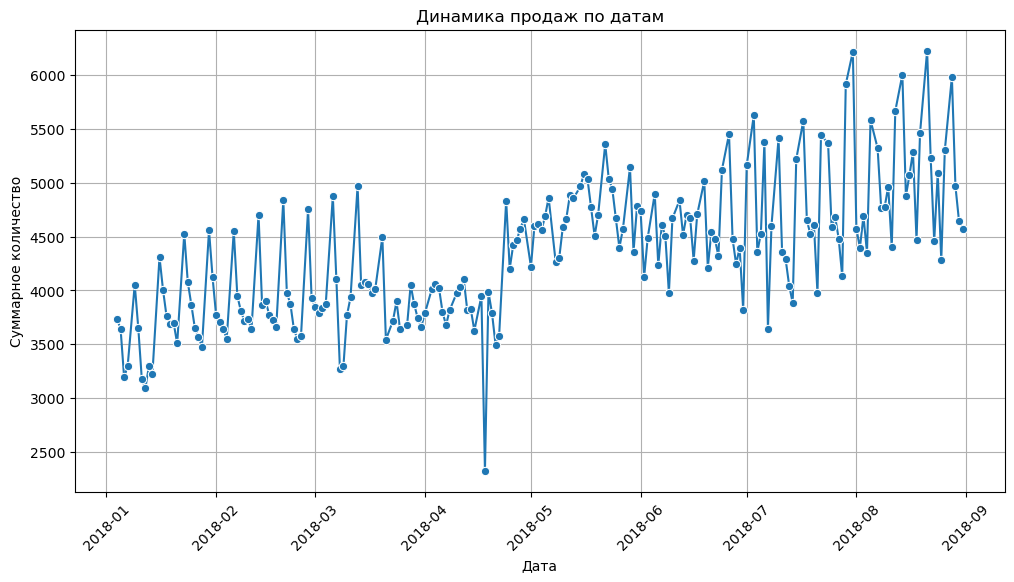

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем размер графика
plt.figure(figsize=(12, 6))

# Строим линейный график
sns.lineplot(data=grouped_df, x='Дата', y='Количество', marker='o')

# Добавляем название и подписи осей
plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Суммарное количество')
plt.grid(True) # Добавляем сетку для удобства
plt.xticks(rotation=45) # Поворачиваем даты, чтобы они не накладывались

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
# На графике представлена динамика продаж за период с января по сентябрь 2018 года.
# 1. Основные тренды
# Общий рост: Наблюдается явный восходящий тренд. Если в начале года (январь) продажи колебались в районе 3000–4500 единиц, то к августу они вышли на уровень 4500–6000+ единиц.
# Цикличность: График имеет ярко выраженную «пилообразную» форму. Это говорит о сильной сезонности (вероятно, недельной): резкие пики продаж чередуются с такими же регулярными спадами.
# 2. Ключевые периоды
# Январь — Март: Период относительной стабильности с постепенным ростом. Продажи редко превышают отметку в 5000.
# Апрель: Виден самый глубокий аномальный провал (середина апреля), где продажи упали ниже 2500. Это может быть связано с техническим сбоем в данных, праздниками или отсутствием поставок.
# Май — Август: Фаза активного роста и увеличения волатильности. Разброс между минимальными и максимальными значениями в течение недели становится гораздо сильнее. В августе зафиксированы абсолютные максимумы — свыше 6000 единиц.
# 3. Визуальные характеристики
# Оси: По горизонтали (X) — шкала времени по месяцам. По вертикали (Y) — суммарное количество проданного товара.
# Стиль: Использован линейный график с маркерами в узлах данных, что позволяет видеть каждое конкретное значение. Сетка помогает точно определить уровень продаж в любой точке.
# Резюме: Бизнес демонстрирует уверенный рост, однако амплитуда колебаний увеличивается. Стоит обратить внимание на причину резкого падения в апреле и изучить природу еженедельных пиков.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [8]:
# Находим строку с минимальным количеством
outlier_low = df[df['Количество'] == df['Количество'].min()]
print(outlier_low)

# Находим строку с максимальным количеством
outlier_high = df[df['Количество'] == df['Количество'].max()]
print(outlier_high)

             Дата  Склад   Контрагент Номенклатура  Количество
6      2018-01-04      1    address_0    product_6           0
9      2018-01-04      1    address_0    product_9           0
32     2018-01-04      1    address_1   product_12           0
36     2018-01-04      1    address_1   product_15           0
38     2018-01-04      1    address_2    product_0           0
...           ...    ...          ...          ...         ...
301331 2018-08-31      5  address_172    product_2           0
301343 2018-08-31      5  address_173    product_2           0
301346 2018-08-31      5  address_173    product_5           0
301350 2018-08-31      5  address_173   product_15           0
301353 2018-08-31      5  address_173   product_19           0

[31425 rows x 5 columns]
             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [9]:
df['Дата'] = pd.to_datetime(df['Дата'])

# 2. Фильтруем данные:
# - Склад №3
# - Июнь (6), Июль (7), Август (8)
# - Среда (у pandas день недели под индексом 2, где 0 - понедельник)
filtered_df = df[
    (df['Склад'] == 3) & 
    (df['Дата'].dt.month.isin([6, 7, 8])) & 
    (df['Дата'].dt.dayofweek == 2)
]

# 3. Группируем по товару и считаем сумму продаж
top_product = filtered_df.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False)

# Выводим самый популярный товар
print("Топ-товар по средам (июнь-август, склад 3):")
print(top_product.head(1))

Топ-товар по средам (июнь-август, склад 3):
Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

C:\Users\Приветствую\AppData\Local\Temp\ipykernel_28576\3431405042.py:10: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  weather_df['Местное время в Астане'] = pd.to_datetime(weather_df['Местное время в Астане'])


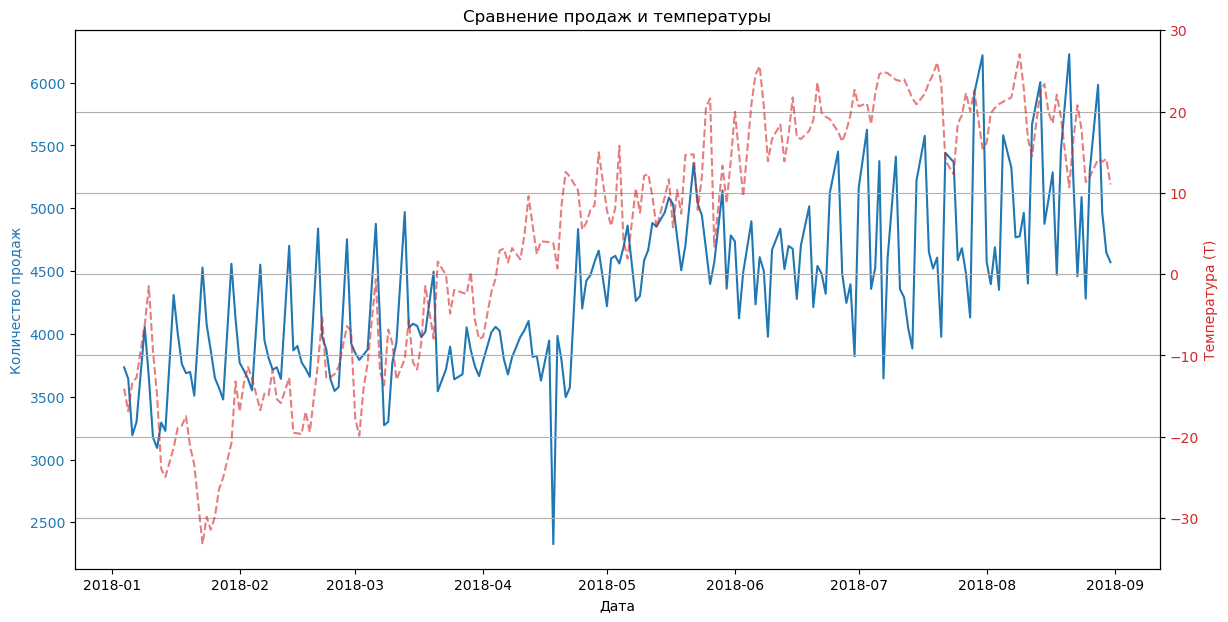

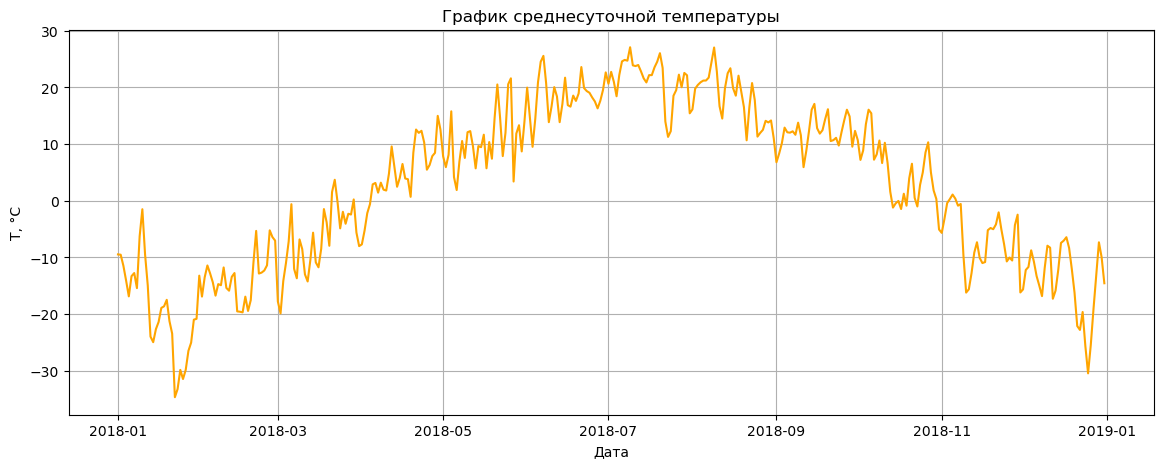

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Загрузка данных погоды (пропускаем комментарии в начале файла RP5)
# Обычно в RP5 разделитель ';' и кодировка 'utf-8' или 'cp1251'
weather_df = pd.read_csv('Weather2018.csv', sep=';', skiprows=6, index_col=False)

# 2. Преобразование даты и расчет средней температуры за день
# В RP5 столбец с временем обычно называется 'Местное время в Астане'
weather_df['Местное время в Астане'] = pd.to_datetime(weather_df['Местное время в Астане'])
weather_df['Дата'] = weather_df['Местное время в Астане'].dt.date

# 'T' — столбец с температурой воздуха в данных RP5
daily_temp = weather_df.groupby('Дата')['T'].mean().reset_index()
daily_temp['Дата'] = pd.to_datetime(daily_temp['Дата'])

# 3. Объединение с вашим grouped_df
# Убедитесь, что в grouped_df столбец 'Дата' также имеет формат datetime
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата'])
merged_df = pd.merge(grouped_df, daily_temp, on='Дата', how='inner')

# 4. Построение совмещенного графика
fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='tab:blue')
ax1.plot(merged_df['Дата'], merged_df['Количество'], color='tab:blue', label='Продажи')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx() # Создаем вторую ось Y для температуры
ax2.set_ylabel('Температура (T)', color='tab:red')
ax2.plot(merged_df['Дата'], merged_df['T'], color='tab:red', linestyle='--', alpha=0.6, label='Температура')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Сравнение продаж и температуры')
plt.grid(True)
plt.show()

# 5. Отдельный график температуры
plt.figure(figsize=(14, 5))
plt.plot(daily_temp['Дата'], daily_temp['T'], color='orange')
plt.title('График среднесуточной температуры')
plt.xlabel('Дата')
plt.ylabel('T, °C')
plt.grid(True)
plt.show()